In [21]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time
#JAVA_HOME_PATH = "/usr/lib/jvm/java-17-openjdk-amd64"
JAVA_HOME_PATH = '/opt/homebrew/Cellar/openjdk@17/17.0.19'
# JAVA_HOME_PATH = 'C:/Program Files/Java/jdk-17'
# HADOOP_HOME = 'C:/hadoop'
# Установка критических переменных окружения
os.environ["JAVA_HOME"] = JAVA_HOME_PATH
os.environ["PATH"] = f"{JAVA_HOME_PATH}/bin:{os.environ['PATH']}"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
#os.environ['HADOOP_HOME'] = HADOOP_HOME



spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

spark.conf.set("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true")

In [22]:
import pandas as pd

pd.read_csv("combined_data.csv").head()

,label,email
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [23]:
schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

/Users/dmitrijkostukov/PycharmProjects/SpamFilter/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:416: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


In [24]:
spark.range(5).show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [25]:
df.printSchema()
df.show(10)

root
 |-- label: integer (nullable = false)
 |-- email: string (nullable = true)

+-----+--------------------+
|label|               email|
+-----+--------------------+
|    1|ounce feather bow...|
|    1|wulvob get your m...|
|    0| computer connect...|
|    1|university degree...|
|    0|thanks for all yo...|
|    0|larry king live a...|
|    0|michael pobega wr...|
|    0|hi i have this er...|
|    1|works gateway wor...|
|    1|upon this account...|
+-----+--------------------+
only showing top 10 rows


26/05/09 16:54:03 WARN TaskSetManager: Stage 5 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
Traceback (most recent call last):
  File "/Users/dmitrijkostukov/PycharmProjects/SpamFilter/venv/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
  File "/Users/dmitrijkostukov/PycharmProjects/SpamFilter/venv/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
BrokenPipeError: [Errno 32] Broken pipe


In [26]:
# model.get("lottery")
# model.get("sale")

In [27]:
# def predict_bayes(word):
#     word = word.lower()
#     num_spam_with_word = model[word]['spam']
#     num_ham_with_word = model[word]['ham']
#     return 1.0*num_spam_with_word/(num_spam_with_word + num_ham_with_word)

In [28]:
# predict_bayes("sale")

In [29]:
# print(type(local_data))

In [30]:
# emails = new_df

# def predict_naive_bayes(email):
#     total = emails.count()
#     num_spam = emails.where("label=1").count()
#     num_ham = total - num_spam
    
#     # Исправление опечатки
#     words = set(email.strip().split())
    
#     log_spam_prob = log(num_spam / total)  # Логарифм P(спам)
#     log_ham_prob = log(num_ham / total)    # Логарифм P(не спам)
    
#     alpha = 1e-6  # Параметр сглаживания для новых слов
    
#     for word in words:
#         if word in model:
#             # Правильное вычисление логарифмов вероятностей
#             log_spam_prob += log(model[word]['spam'] / num_spam)
#             log_ham_prob += log(model[word]['ham'] / num_ham)
#         else:
#             # Сглаживание для новых слов
#             log_spam_prob += log(alpha)
#             log_ham_prob += log(alpha)
    
#     # Преобразуем обратно в вероятности с защитой от переполнения
#     log_ratio = log_spam_prob - log_ham_prob
#     probability = 1 / (1 + exp(-log_ratio))
    
#     return probability

In [31]:
# predict_naive_bayes("meet me at")

In [32]:
# predict_naive_bayes("lottery sale")

In [33]:
# predict_naive_bayes("hi mom how are you")

In [34]:
# predict_naive_bayes("a")

In [35]:
# predict_naive_bayes("hi dad")

In [36]:
# predict_naive_bayes("meet me at the lobby of the hotel at nine am")

In [37]:
# small_df = spark.read.csv("emails.csv", header=True)
# small_df.printSchema()
# small_df.show(20)

In [38]:
# model.get("mom")

In [39]:
# model.get("hi")

In [40]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import NaiveBayes
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
bayes_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=500000, minDF=5)
# 4. Классификатор
nb = NaiveBayes(featuresCol="features", labelCol="label", modelType="multinomial")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, nb])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
bayes_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = bayes_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
bayes_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {bayes_accuracy:.4f}")
bayes_end = time.time()

26/05/09 16:54:04 WARN TaskSetManager: Stage 6 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:54:16 WARN TaskSetManager: Stage 10 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:54:24 WARN DAGScheduler: Broadcasting large task binary with size 1008.3 KiB
26/05/09 16:54:24 WARN TaskSetManager: Stage 13 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:54:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Accuracy: 0.9696


In [41]:
from pyspark.sql import Row

# 1. Создаём DataFrame с новым сообщением
new_text = "hi mom how are you?"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = bayes_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

+-------------------+----------+
|              email|prediction|
+-------------------+----------+
|hi mom how are you?|       0.0|
+-------------------+----------+



In [42]:
bayes_model.write().overwrite().save("models/spam_model_bayes")

26/05/09 16:54:31 WARN TaskSetManager: Stage 23 contains a task of very large size (1090 KiB). The maximum recommended task size is 1000 KiB.


In [43]:
from pyspark.ml.pipeline import PipelineModel

loaded_model = PipelineModel.load("models/spam_model_bayes")
new_text = "hi mom how are you?"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = loaded_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

+-------------------+----------+
|              email|prediction|
+-------------------+----------+
|hi mom how are you?|       0.0|
+-------------------+----------+



In [44]:
new_text = "hi mom how are you"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = loaded_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

+------------------+----------+
|             email|prediction|
+------------------+----------+
|hi mom how are you|       0.0|
+------------------+----------+



In [45]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
lr_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
lr = LogisticRegression(featuresCol="features", labelCol="label")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, lr])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
lr_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = lr_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
lr_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {lr_accuracy:.4f}")
lr_end = time.time()

26/05/09 16:54:37 WARN TaskSetManager: Stage 47 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:54:47 WARN TaskSetManager: Stage 51 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:54:57 WARN TaskSetManager: Stage 54 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:55:07 WARN TaskSetManager: Stage 57 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:55:07 WARN TaskSetManager: Stage 60 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:55:08 WARN TaskSetManager: Stage 63 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:55:08 WARN TaskSetManager: Stage 66 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/

Accuracy: 0.9770


In [46]:
print(df.count())
print(df.where("label>0").count())
print(df.where("label=1").count())
print(df.where("label=0").count())

26/05/09 16:56:06 WARN TaskSetManager: Stage 407 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:56:07 WARN TaskSetManager: Stage 410 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.


83448


26/05/09 16:56:09 WARN TaskSetManager: Stage 413 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.


43910


26/05/09 16:56:11 WARN TaskSetManager: Stage 416 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.


43910


39538


In [47]:
lr_model.write().overwrite().save("models/spam_model_lr")

26/05/09 16:56:13 WARN TaskSetManager: Stage 423 contains a task of very large size (1886 KiB). The maximum recommended task size is 1000 KiB.


In [48]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [49]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import DecisionTreeClassifier

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
dt_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, dt])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
dt_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = dt_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
dt_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {dt_accuracy:.4f}")
dt_end = time.time()

26/05/09 16:56:17 WARN TaskSetManager: Stage 0 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:56:31 WARN TaskSetManager: Stage 4 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:56:34 WARN TaskSetManager: Stage 7 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:56:34 WARN TaskSetManager: Stage 8 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:56:42 WARN DAGScheduler: Broadcasting large task binary with size 1052.1 KiB
26/05/09 16:56:42 WARN TaskSetManager: Stage 9 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 16:57:44 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/05/09 16:57:44 WARN TaskSetManager: Stage 11 contains a task of very large size (3368 KiB). The maximum recommended t

Accuracy: 0.8419


In [50]:
dt_model.write().overwrite().save("models/spam_model_dt")

26/05/09 17:00:19 WARN TaskSetManager: Stage 27 contains a task of very large size (1885 KiB). The maximum recommended task size is 1000 KiB.


In [51]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [52]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import RandomForestClassifier

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
rf_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, rf])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
rf_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = rf_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rf_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {rf_accuracy:.4f}")
rf_end = time.time()

26/05/09 17:00:23 WARN TaskSetManager: Stage 0 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:00:33 WARN TaskSetManager: Stage 4 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:00:35 WARN TaskSetManager: Stage 7 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:00:35 WARN TaskSetManager: Stage 8 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:00:42 WARN DAGScheduler: Broadcasting large task binary with size 1052.2 KiB
26/05/09 17:00:42 WARN TaskSetManager: Stage 9 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:01:28 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/05/09 17:01:28 WARN TaskSetManager: Stage 11 contains a task of very large size (3368 KiB). The maximum recommended t

Accuracy: 0.8041


In [53]:
rf_model.write().overwrite().save("models/spam_model_rf")

26/05/09 17:03:42 WARN TaskSetManager: Stage 27 contains a task of very large size (1885 KiB). The maximum recommended task size is 1000 KiB.


In [54]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [55]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LinearSVC  # Импорт SVM
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Фильтрация пустых значений
svm_start = time.time()
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=100000, 
    minDF=1
)

# 4. Классификатор SVM (LinearSVC)
svm = LinearSVC(
    featuresCol="features", 
    labelCol="label",
    maxIter=10,          # Количество итераций
    regParam=0.1         # Параметр регуляризации
)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, svm])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
svm_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = svm_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
svm_accuracy = evaluator.evaluate(predictions)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
svm_end = time.time()
# Дополнительные метрики (F1, Precision, Recall)
evaluator.setMetricName("f1").evaluate(predictions)
evaluator.setMetricName("weightedPrecision").evaluate(predictions)
evaluator.setMetricName("weightedRecall").evaluate(predictions)

26/05/09 17:03:46 WARN TaskSetManager: Stage 0 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:03:56 WARN TaskSetManager: Stage 4 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:04:07 WARN TaskSetManager: Stage 7 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:04:24 WARN TaskSetManager: Stage 10 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:04:26 WARN TaskSetManager: Stage 13 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:04:30 WARN TaskSetManager: Stage 16 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:04:35 WARN TaskSetManager: Stage 19 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 

SVM Accuracy: 0.9834


26/05/09 17:05:37 WARN TaskSetManager: Stage 74 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:05:44 WARN TaskSetManager: Stage 76 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.


0.983443048075005

In [56]:
svm_model.write().overwrite().save("models/spam_model_svm")

26/05/09 17:05:53 WARN TaskSetManager: Stage 82 contains a task of very large size (1886 KiB). The maximum recommended task size is 1000 KiB.


In [57]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "32g") \
    .config("spark.executor.memory", "32g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("combined_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [58]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import GBTClassifier  # Импорт GBT
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
gbt_start = time.time()
# Фильтрация пустых значений
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=10000, 
    minDF=1
)

# 4. Классификатор GBT (Gradient-Boosted Trees)
gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="label",
    maxIter=50,           # Количество деревьев (аналог n_estimators)
    maxDepth=5,           # Глубина дерева
    stepSize=0.1,         # Скорость обучения (learning rate)
    subsamplingRate=0.8,  # Доля данных для каждого дерева
    seed=42
)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, gbt])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
gbt_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = gbt_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
gbt_accuracy = evaluator.evaluate(predictions)
print(f"GBT Accuracy: {gbt_accuracy:.4f}")
gbt_end = time.time()
# Дополнительные метрики
print(f"F1-score: {evaluator.setMetricName('f1').evaluate(predictions):.4f}")
print(f"Precision: {evaluator.setMetricName('weightedPrecision').evaluate(predictions):.4f}")
print(f"Recall: {evaluator.setMetricName('weightedRecall').evaluate(predictions):.4f}")

26/05/09 17:05:58 WARN TaskSetManager: Stage 0 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:06:14 WARN TaskSetManager: Stage 4 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:06:15 WARN TaskSetManager: Stage 5 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:06:27 WARN TaskSetManager: Stage 6 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:06:45 WARN TaskSetManager: Stage 8 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:07:03 WARN TaskSetManager: Stage 10 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:07:05 WARN TaskSetManager: Stage 12 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17

GBT Accuracy: 0.9551


F1-score: 0.9550


26/05/09 17:21:16 WARN TaskSetManager: Stage 512 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.


Precision: 0.9563


26/05/09 17:21:29 WARN TaskSetManager: Stage 514 contains a task of very large size (3368 KiB). The maximum recommended task size is 1000 KiB.


Recall: 0.9551


In [59]:
gbt_model.write().overwrite().save("models/spam_model_gbt")

In [60]:
print("bayes_accuracy:", bayes_accuracy, 'time', bayes_end - bayes_start)
print("lr_accuracy:", lr_accuracy, 'time', lr_end - lr_start)
print("dt_accuracy:", dt_accuracy, 'time', dt_end - dt_start)
print("svm_accurac:", svm_accuracy, 'time', svm_end - svm_start)
print("gbt_accuracy:", gbt_accuracy, 'time', gbt_end - gbt_start)
print("rf_accuracy:", rf_accuracy, 'time', rf_end - rf_start)

bayes_accuracy: 0.969638938759226 time 25.223538875579834
lr_accuracy: 0.9769798523838021 time 89.15094113349915
dt_accuracy: 0.8418511869140235 time 240.57034182548523
svm_accurac: 0.9834430480750049 time 93.23935627937317
gbt_accuracy: 0.9551166965888689 time 910.3359491825104
rf_accuracy: 0.8040694195092759 time 198.98255491256714


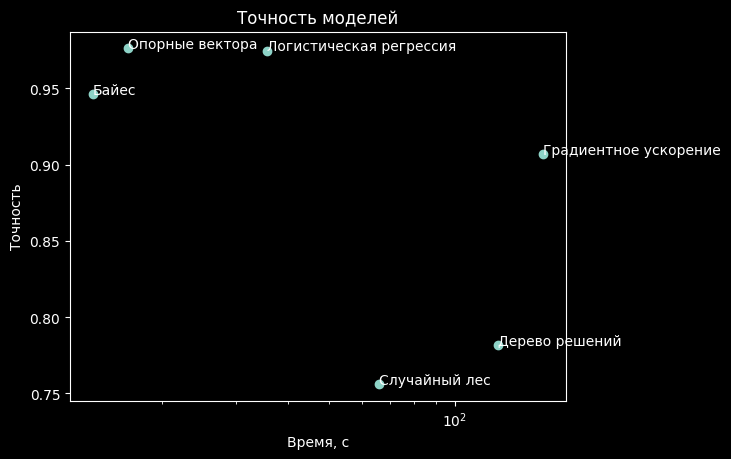

In [61]:
# Create the plot as requested

import matplotlib.pyplot as plt

# Data from the user
models = ["Байес", "Логистическая регрессия", "Дерево решений", "Опорные вектора", "Градиентное ускорение", "Случайный лес"]
accuracy = [0.9463559901806914, 0.9747675962815405, 0.7816411123184032, 0.9762767113364723, 0.9070385126162018, 0.7560062779186285]
time_sec = [13.65663743019104, 35.54560589790344, 126.84595847129822, 16.590663194656372, 162.83224296569824, 65.89334487915039]

plt.figure()

# Scatter plot
plt.scatter(time_sec, accuracy)

# Annotate points with model names
for i, model in enumerate(models):
    plt.annotate(model, (time_sec[i], accuracy[i]))

# Use logarithmic scale for time axis to handle uneven scale
plt.xscale('log')

plt.xlabel("Время, с")
plt.ylabel("Точность")
plt.title("Точность моделей")

plt.show()

In [62]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time

spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [63]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LinearSVC  # Импорт SVM
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Фильтрация пустых значений
svm_start = time.time()
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=100_000_000, 
    minDF=1
)

# 4. Классификатор SVM (LinearSVC)
svm = LinearSVC(
    featuresCol="features", 
    labelCol="label",
    maxIter=1000,          # Количество итераций
    regParam=0.1,         # Параметр регуляризации   # <-- добавляем
)
# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, svm])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
svm_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = svm_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
svm_accuracy = evaluator.evaluate(predictions)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
svm_end = time.time()
# Дополнительные метрики (F1, Precision, Recall)
evaluator.setMetricName("f1").evaluate(predictions)
evaluator.setMetricName("weightedPrecision").evaluate(predictions)
evaluator.setMetricName("weightedRecall").evaluate(predictions)

26/05/09 17:21:51 WARN TaskSetManager: Stage 0 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:22:22 WARN TaskSetManager: Stage 4 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:22:57 WARN TaskSetManager: Stage 7 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:23:31 WARN TaskSetManager: Stage 10 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:23:41 WARN TaskSetManager: Stage 13 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:23:54 WARN TaskSetManager: Stage 16 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 17:24:01 WARN TaskSetManager: Stage 19 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 

SVM Accuracy: 0.9779


26/05/09 18:21:51 WARN TaskSetManager: Stage 3963 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:22:15 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
26/05/09 18:22:15 WARN TaskSetManager: Stage 3965 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:22:33 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
26/05/09 18:22:33 WARN TaskSetManager: Stage 3967 contains a task of very large size (8579 KiB). The maximum recommended task size is 1000 KiB.


0.9779370657295743

In [64]:
svm_model.write().overwrite().save("models/spam_model_svm_ru")

26/05/09 18:22:57 WARN TaskSetManager: Stage 3973 contains a task of very large size (14127 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:22:58 WARN TaskSetManager: Stage 3975 contains a task of very large size (4687 KiB). The maximum recommended task size is 1000 KiB.


In [65]:
print("SVM:", svm_accuracy, 'time', svm_end - svm_start)

SVM: 0.9779370657295743 time 3601.309595823288


In [66]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time

spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("russian_data.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [67]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
lr_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered",locale='ru')
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
lr = LogisticRegression(featuresCol="features", labelCol="label")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, lr])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
lr_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = lr_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
lr_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {lr_accuracy:.4f}")
lr_end = time.time()

26/05/09 18:23:13 WARN TaskSetManager: Stage 0 contains a task of very large size (4003 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:23:25 WARN TaskSetManager: Stage 4 contains a task of very large size (4003 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:23:31 WARN TaskSetManager: Stage 7 contains a task of very large size (4003 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:23:39 WARN TaskSetManager: Stage 10 contains a task of very large size (4003 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:23:40 WARN TaskSetManager: Stage 13 contains a task of very large size (4003 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:23:42 WARN TaskSetManager: Stage 16 contains a task of very large size (4003 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 18:23:42 WARN TaskSetManager: Stage 19 contains a task of very large size (4003 KiB). The maximum recommended task size is 1000 KiB.
26/05/09 

Accuracy: 0.9642


In [68]:
lr_model.write().overwrite().save("models/spam_model_lr_ru")

26/05/09 18:25:11 WARN TaskSetManager: Stage 343 contains a task of very large size (2535 KiB). The maximum recommended task size is 1000 KiB.


In [69]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time

spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [70]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time

spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions",
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [71]:
lr_model.write().overwrite().save("models/spam_model_lr_ru_big")

26/05/09 18:25:32 WARN TaskSetManager: Stage 4 contains a task of very large size (2535 KiB). The maximum recommended task size is 1000 KiB.
26/05/10 03:12:39 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 996681 ms exceeds timeout 120000 ms
26/05/10 03:12:39 WARN SparkContext: Killing executors is not supported by current scheduler.
26/05/10 03:12:48 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockM